# Data Quality Framework: Validation, Anomalies, and Remediation

**Docker image**: `ml4t`

## Purpose
Demonstrate the four pillars of a production data-quality pipeline applied to
US equities daily OHLCV: structural validation (OHLC invariants, nulls,
duplicates), anomaly detection (return outliers, volume spikes, price
staleness), distribution drift (PSI), and ingestion hygiene (gaps,
duplicates, corporate-action detection). All checks come from the
`ml4t.data.validation` and `ml4t.data.anomaly` modules.

## Learning Objectives
- Run `OHLCVValidator` and read its issue report.
- Compare MAD / Z-score / IQR thresholds for return-outlier detection.
- Compute Population Stability Index for drift monitoring and read its bins.
- Detect ingestion gaps, duplicates, and likely corporate actions, and wire
  the pieces together into a quarantine-aware pipeline.

## Book reference
Chapter 2, §2.3 (data quality framework). Downstream chapters that consume
the cleaned panel: `14_point_in_time_validation` (bitemporal hygiene),
`15_survivorship_bias_detection`, `17_complete_pipeline`.

## Prerequisites
- Quandl/Wiki US equities parquet materialized under `ML4T_DATA_PATH`
  (the legacy dataset; ends 2018-03-27).
- Loader `data.load_us_equities`.
- Library packages `ml4t.data.validation` and `ml4t.data.anomaly`.

In [1]:
"""Data Quality Framework — Validation, anomaly detection, and remediation."""

import warnings

warnings.filterwarnings("ignore")

import logging
from datetime import datetime
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
import structlog
from ml4t.data.anomaly import (
    AnomalyManager,
    PriceStalenessDetector,
    ReturnOutlierDetector,
    VolumeSpikeDetector,
)
from ml4t.data.anomaly.config import (
    AnomalyConfig,
    PriceStalenessConfig,
    ReturnOutlierConfig,
    VolumeSpikeConfig,
)
from ml4t.data.validation import OHLCVValidator

from data import load_us_equities
from utils.paths import get_output_dir
from utils.style import COLORS

# The anomaly/validation libraries log per-symbol detector results through
# structlog, which bypasses stdlib logging; filter at WARNING so the cells show
# call results, not the library's internal debug stream.
structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.WARNING))


def _to_date(value: object) -> object:
    """Normalize a polars timestamp scalar to a datetime.date for printing."""
    return value.date() if hasattr(value, "date") else value

In [2]:
# Five large-cap symbols from the legacy Wiki/Quandl dataset (1962–2018).
# FB (not META) is the canonical Facebook ticker in this vintage. Readers can
# override this universe via Papermill.
SYMBOLS = ["AAPL", "MSFT", "GOOGL", "NVDA", "FB"]

In [3]:
OUTPUT_DIR = get_output_dir(2, "quality")

## Load Sample Data

Use the pre-2018 Wiki/Quandl US equities panel. The validation and anomaly
detectors operate on any DataFrame with `timestamp / open / high / low /
close / volume`.

In [4]:
wiki_df = load_us_equities()
print(
    f"US equities loaded: {len(wiki_df):,} rows; "
    f"{wiki_df['timestamp'].min()} → {wiki_df['timestamp'].max()}"
)

datasets = {
    symbol: (
        wiki_df.lazy()
        .filter(pl.col("symbol") == symbol)
        .select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])
        .collect()
    )
    for symbol in SYMBOLS
}
missing = [s for s, df in datasets.items() if df.is_empty()]
if missing:
    raise RuntimeError(f"Symbols missing from Wiki/Quandl dataset: {missing}")

per_symbol_rows = pl.DataFrame(
    {"symbol": list(datasets), "rows": [len(df) for df in datasets.values()]}
)
per_symbol_rows

US equities loaded: 15,389,314 rows; 1962-01-02 → 2018-03-27


symbol,rows
str,i64
"""AAPL""",9400
"""MSFT""",8076
"""GOOGL""",3424
"""NVDA""",4825
"""FB""",1472


---

## Part 1: OHLC Invariant Validation

**OHLC Invariants** are mathematical relationships that MUST hold for valid
market data:

| Invariant       | Meaning              |
|-----------------|----------------------|
| High ≥ Low      | by definition        |
| High ≥ Open, Close | high is the maximum |
| Low ≤ Open, Close  | low is the minimum  |
| Prices > 0      | no negative prices   |
| Volume ≥ 0      | no negative volume   |

Violations indicate provider errors, transmission corruption, or incorrect
adjustments.

In [5]:
validator = OHLCVValidator(
    check_nulls=True,
    check_price_consistency=True,
    check_negative_prices=True,
    check_negative_volume=True,
    check_duplicate_timestamps=True,
    check_chronological_order=True,
    check_price_staleness=True,
    check_extreme_returns=True,
    max_return_threshold=0.5,  # flag |return| > 50%
    staleness_threshold=5,  # flag 5+ identical-price days
)

validation_summary = pl.DataFrame(
    [
        {
            "symbol": sym,
            "passed": (r := validator.validate(df)).passed,
            "issues": len(r.issues),
            "critical": r.critical_count,
            "errors": r.error_count,
        }
        for sym, df in datasets.items()
    ]
)
validation_summary

symbol,passed,issues,critical,errors
str,bool,i64,i64,i64
"""AAPL""",true,1,0,0
"""MSFT""",true,1,0,0
"""GOOGL""",true,0,0,0
"""NVDA""",true,1,0,0
"""FB""",true,0,0,0


### Validation on Dirty Data

Inject three known faults into AAPL and re-run the validator to see what it
catches.

In [6]:
clean_df = datasets["AAPL"]
highs = clean_df["high"].to_numpy().copy()
lows = clean_df["low"].to_numpy().copy()
volumes = clean_df["volume"].to_numpy().copy()

# Fault 1: high < low at rows 10–12
highs[10:13] = lows[10:13] - 1.0
# Fault 2: negative volume at row 20
volumes[20] = -1000
# Fault 3: null close at row 30. Use a genuine null, not NumPy NaN: Polars stores
# np.nan as a float NaN that the null check ignores, so only a real null exercises
# OHLCVValidator's check_nulls.
close_col = pl.Series("close", clean_df["close"].to_numpy()).scatter(30, None)

dirty_df = pl.DataFrame(
    {
        "timestamp": clean_df["timestamp"],
        "symbol": clean_df["symbol"],
        "open": clean_df["open"],
        "high": highs,
        "low": lows,
        "close": close_col,
        "volume": volumes,
    }
)

dirty_result = validator.validate(dirty_df)
print(f"Validation passed: {dirty_result.passed}")
print(f"Critical: {dirty_result.critical_count}, Errors: {dirty_result.error_count}")

dirty_issues = pl.DataFrame(
    [
        {
            "severity": issue.severity.name,
            "check": issue.check,
            "rows": issue.row_count or 0,
            "message": issue.message,
        }
        for issue in dirty_result.issues
    ]
)
dirty_issues

Validation passed: False
Critical: 0, Errors: 4


severity,check,rows,message
str,str,i64,str
"""ERROR""","""null_values""",1,"""Found 1 null values in 'close'…"
"""ERROR""","""price_consistency""",3,"""Found 3 rows where high < low"""
"""ERROR""","""price_consistency""",3,"""Found 3 rows where high < open…"
"""ERROR""","""negative_volume""",1,"""Found 1 rows with negative vol…"
"""WARNING""","""extreme_returns""",2,"""Found 2 extreme returns (>50%)"""


---

## Part 2: Anomaly Detection

Validation checks data correctness; anomaly detection finds unusual patterns
in otherwise structurally-valid data:

| Detector              | What it finds                | Method                 |
|-----------------------|-------------------------------|------------------------|
| ReturnOutlierDetector | flash crashes, splits, pumps  | MAD, Z-score, IQR      |
| VolumeSpikeDetector   | unusual trading activity      | rolling Z-score        |
| PriceStalenessDetector| data gaps, illiquid securities| consecutive-unchanged  |

### ReturnOutlierDetector

Flags returns whose magnitude exceeds a threshold under three statistics:
**MAD** (median absolute deviation, robust to extreme tails), **Z-score**
(Gaussian, threshold-sensitive to fat tails), and **IQR** (interquartile
range, distribution-free).

In [7]:
sample_df = datasets["AAPL"]
methods = ["mad", "zscore", "iqr"]

method_summary = pl.DataFrame(
    [
        {
            "method": m,
            "anomalies": len(
                ReturnOutlierDetector(
                    config=ReturnOutlierConfig(method=m, threshold=3.0, min_samples=20)
                ).detect(sample_df, symbol="AAPL")
            ),
        }
        for m in methods
    ]
)
method_summary

method,anomalies
str,i64
"""mad""",336
"""zscore""",83
"""iqr""",69


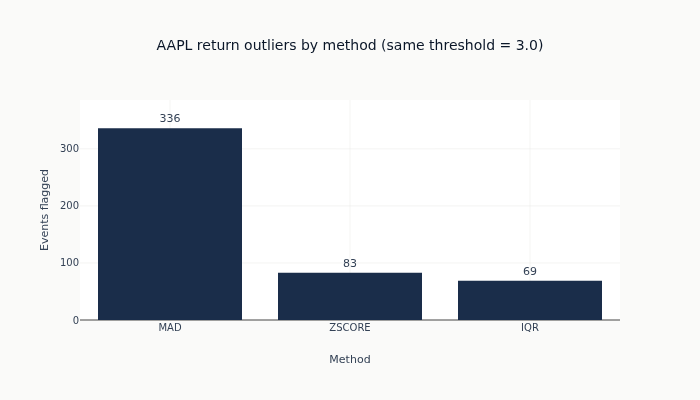

In [8]:
fig = go.Figure(
    go.Bar(
        x=[m.upper() for m in method_summary["method"].to_list()],
        y=method_summary["anomalies"].to_list(),
        marker_color=COLORS["slate"],
        text=method_summary["anomalies"].to_list(),
        textposition="outside",
    )
)
fig.update_layout(
    title="AAPL return outliers by method (same threshold = 3.0)",
    xaxis_title="Method",
    yaxis_title="Events flagged",
    height=400,
)
fig.show()

MAD flags the most events because it is more sensitive in the tails of a
heavy-tailed return distribution. The biggest "anomalies" in the AAPL series
below are *real* events: stock splits and an earnings-driven crash, not
data-quality issues. The detector cannot distinguish — that is the operator's
job downstream.

In [9]:
mad_anomalies = ReturnOutlierDetector(
    config=ReturnOutlierConfig(method="mad", threshold=3.0, min_samples=20)
).detect(sample_df, symbol="AAPL")

top_mad = pl.DataFrame(
    [
        {
            "date": _to_date(a.timestamp),
            "return_pct": float(a.value),  # value is already a percentage
        }
        for a in sorted(mad_anomalies, key=lambda x: abs(x.value), reverse=True)[:5]
    ]
)
top_mad

date,return_pct
date,f64
2014-06-09,-85.485695
2000-09-29,-51.869159
2005-02-28,-49.589842
1987-06-16,-47.133758
2000-06-21,-45.05679


Plotting the daily-return series with the MAD-flagged points on top makes the
operator's problem concrete: the largest flags are not glitches but the 2014
7:1 split, the 2000 earnings crash, and the earlier 2:1 splits. A detector
finds the outliers; only a human (or a corporate-action feed) can say which
are data errors and which are the market.

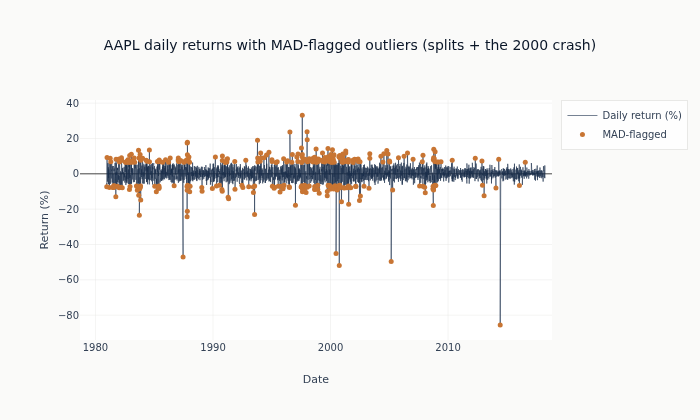

In [10]:
returns_df = sample_df.with_columns((pl.col("close").pct_change() * 100).alias("return_pct"))
anomaly_dates = {_to_date(a.timestamp) for a in mad_anomalies}
flagged = returns_df.with_columns(
    pl.col("timestamp")
    .map_elements(lambda t: _to_date(t) in anomaly_dates, return_dtype=pl.Boolean)
    .alias("flagged")
)
flagged_pts = flagged.filter(pl.col("flagged"))

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=returns_df["timestamp"].to_list(),
        y=returns_df["return_pct"].to_list(),
        mode="lines",
        line=dict(color=COLORS["slate"], width=0.6),
        name="Daily return (%)",
    )
)
fig.add_trace(
    go.Scatter(
        x=flagged_pts["timestamp"].to_list(),
        y=flagged_pts["return_pct"].to_list(),
        mode="markers",
        marker=dict(color=COLORS["copper"], size=5),
        name="MAD-flagged",
    )
)
fig.update_layout(
    title="AAPL daily returns with MAD-flagged outliers (splits + the 2000 crash)",
    xaxis_title="Date",
    yaxis_title="Return (%)",
    height=420,
)
fig.show()

### VolumeSpikeDetector

Flags rolling-window volume Z-scores above a threshold.

In [11]:
volume_anomalies = VolumeSpikeDetector(
    config=VolumeSpikeConfig(window=20, threshold=3.0, min_volume=0, min_samples=20)
).detect(sample_df, symbol="AAPL")

top_volume = pl.DataFrame(
    [
        {
            "date": _to_date(a.timestamp),
            "volume": int(a.value),
            "ratio_vs_avg": (
                a.value / a.metadata["average_volume"] if a.metadata.get("average_volume") else None
            ),
        }
        for a in sorted(volume_anomalies, key=lambda x: x.value, reverse=True)[:5]
    ]
)
print(f"Found {len(volume_anomalies)} AAPL volume spikes")
top_volume

Found 180 AAPL volume spikes


date,volume,ratio_vs_avg
date,i64,f64
2014-09-09,189560600,3.209298
2015-01-28,146477063,2.425153
2016-01-27,133369674,2.135948
2000-09-29,132529300,10.224807
2014-09-03,125233100,2.594822


### PriceStalenessDetector

Flags runs of consecutive identical prices — a strong signal of feed
outages or illiquid securities.

In [12]:
stale_anomalies = PriceStalenessDetector(
    config=PriceStalenessConfig(max_unchanged_days=3, check_close_only=False)
).detect(sample_df, symbol="AAPL")
print(f"AAPL stale-price periods (≥4 consecutive days): {len(stale_anomalies)}")

AAPL stale-price periods (≥4 consecutive days): 0


### AnomalyManager: Production Pipeline

`AnomalyManager` orchestrates the three detectors and provides batch
analysis across symbols.

In [13]:
anomaly_config = AnomalyConfig(
    enabled=True,
    report_severity_threshold="warning",
    return_outliers=ReturnOutlierConfig(method="mad", threshold=3.0),
    volume_spikes=VolumeSpikeConfig(window=20, threshold=3.0),
    price_staleness=PriceStalenessConfig(max_unchanged_days=5),
)
manager = AnomalyManager(config=anomaly_config)
reports = manager.analyze_batch(datasets)

batch_summary = pl.DataFrame(
    [
        {
            "symbol": sym,
            "total_anomalies": len(rep.anomalies),
            "critical": len(rep.get_critical_anomalies()),
        }
        for sym, rep in reports.items()
    ]
)
batch_summary

symbol,total_anomalies,critical
str,i64,i64
"""AAPL""",516,59
"""MSFT""",503,74
"""GOOGL""",254,44
"""NVDA""",393,62
"""FB""",104,13


---

## Part 3: Population Stability Index (PSI)

**PSI** measures distribution drift — whether recent data follows the same
distribution as a historical baseline. Useful for detecting regime changes,
data-source switches, and market-structure shifts.

Bin the baseline series into deciles, recompute the same bin boundaries on
the current series, and sum

$$\mathrm{PSI} = \sum_i (p_i^{\text{current}} - p_i^{\text{baseline}})
\log \frac{p_i^{\text{current}}}{p_i^{\text{baseline}}}$$

| PSI       | Interpretation                  |
|-----------|---------------------------------|
| < 0.1     | no significant change           |
| 0.1–0.25  | moderate shift, investigate     |
| > 0.25    | significant shift, action needed|

In [14]:
def calculate_psi(
    baseline: pl.Series, current: pl.Series, n_bins: int = 10, epsilon: float = 1e-6
) -> tuple[float, pl.DataFrame]:
    """Population Stability Index between baseline and current distributions."""
    baseline_clean = baseline.drop_nulls()
    current_clean = current.drop_nulls()

    percentiles = [i * 100 / n_bins for i in range(n_bins + 1)]
    bin_edges = [baseline_clean.quantile(p / 100) for p in percentiles]

    # Ensure unique edges
    unique_edges = [bin_edges[0]]
    for edge in bin_edges[1:]:
        if edge <= unique_edges[-1]:
            edge = unique_edges[-1] + epsilon
        unique_edges.append(edge)

    baseline_counts = np.histogram(baseline_clean.to_numpy(), bins=unique_edges)[0]
    current_counts = np.histogram(current_clean.to_numpy(), bins=unique_edges)[0]
    baseline_pct = np.maximum(baseline_counts / len(baseline_clean), epsilon)
    current_pct = np.maximum(current_counts / len(current_clean), epsilon)

    psi_values = (current_pct - baseline_pct) * np.log(current_pct / baseline_pct)
    breakdown = pl.DataFrame(
        {
            "bin": list(range(1, n_bins + 1)),
            "baseline_pct": baseline_pct.round(4),
            "current_pct": current_pct.round(4),
            "psi_contribution": psi_values.round(4),
        }
    )
    return float(np.sum(psi_values)), breakdown

In [15]:
df = datasets["AAPL"].with_columns((pl.col("close").pct_change() * 100).alias("return_pct"))
midpoint = len(df) // 2
baseline_returns = df["return_pct"][:midpoint]
current_returns = df["return_pct"][midpoint:]

psi_value, psi_breakdown = calculate_psi(baseline_returns, current_returns)
psi_severity = (
    "no significant change"
    if psi_value < 0.1
    else "moderate shift"
    if psi_value < 0.25
    else "significant shift"
)
print(
    f"AAPL daily-return PSI: {psi_value:.4f} ({psi_severity})\n"
    f"Baseline: {_to_date(df['timestamp'][0])} → {_to_date(df['timestamp'][midpoint])}\n"
    f"Current:  {_to_date(df['timestamp'][midpoint])} → {_to_date(df['timestamp'][-1])}"
)
psi_breakdown

AAPL daily-return PSI: 0.1184 (moderate shift)
Baseline: 1980-12-12 → 1999-07-21
Current:  1999-07-21 → 2018-03-27


bin,baseline_pct,current_pct,psi_contribution
i64,f64,f64,f64
1,0.1,0.0668,0.0134
2,0.0998,0.0768,0.006
3,0.1,0.0753,0.007
4,0.1,0.1077,0.0006
5,0.0638,0.1491,0.0724
6,0.1362,0.1466,0.0008
7,0.1,0.1157,0.0023
8,0.0996,0.1104,0.0011
9,0.1002,0.0804,0.0044


The per-bin view shows *where* the drift lives. Bin membership is defined on
the baseline (each bin holds 10% by construction), so any bar that departs
from 10% in the current half is a shift in that part of the return
distribution — here, mass moving out of the extreme-return deciles as the
second half runs calmer than the first.

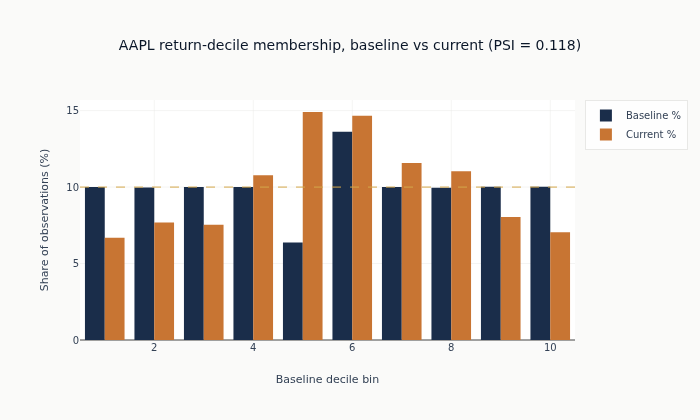

In [16]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=psi_breakdown["bin"].to_list(),
        y=(psi_breakdown["baseline_pct"] * 100).to_list(),
        name="Baseline %",
        marker_color=COLORS["slate"],
    )
)
fig.add_trace(
    go.Bar(
        x=psi_breakdown["bin"].to_list(),
        y=(psi_breakdown["current_pct"] * 100).to_list(),
        name="Current %",
        marker_color=COLORS["copper"],
    )
)
fig.add_hline(y=10, line_dash="dash", line_color=COLORS["amber"], line_width=1)
fig.update_layout(
    title=f"AAPL return-decile membership, baseline vs current (PSI = {psi_value:.3f})",
    xaxis_title="Baseline decile bin",
    yaxis_title="Share of observations (%)",
    barmode="group",
    height=420,
)
fig.show()

---

## Part 4: Data Hygiene

Beyond validation and anomaly detection, ingestion hygiene covers gap
detection, deduplication, and corporate-action signaling.

### Gap Detection

Holidays produce expected 3–4 calendar-day gaps; provider outages and
delistings produce longer ones. The 9/11 close (2001-09-11 → 09-17) is the
only > 5-day gap visible in this universe.

In [17]:
def detect_gaps(df: pl.DataFrame, max_gap_days: int = 5) -> pl.DataFrame:
    """Return rows whose gap from the previous timestamp exceeds `max_gap_days`."""
    return (
        df.sort("timestamp")
        .with_columns(
            pl.col("timestamp").diff().dt.total_days().alias("days_since_prev"),
            pl.col("timestamp").shift(1).alias("prev_timestamp"),
        )
        .filter(pl.col("days_since_prev") > max_gap_days)
        .select(["prev_timestamp", "timestamp", "days_since_prev"])
    )

In [18]:
gap_rows = []
for symbol, df in datasets.items():
    gaps = detect_gaps(df, max_gap_days=5)
    for row in gaps.iter_rows(named=True):
        gap_rows.append(
            {
                "symbol": symbol,
                "prev_date": _to_date(row["prev_timestamp"]),
                "next_date": _to_date(row["timestamp"]),
                "days": int(row["days_since_prev"]),
            }
        )
gap_table = (
    pl.DataFrame(gap_rows)
    if gap_rows
    else pl.DataFrame({"symbol": [], "prev_date": [], "next_date": [], "days": []})
)
gap_table

symbol,prev_date,next_date,days
str,date,date,i64
"""AAPL""",2001-09-10,2001-09-17,7
"""MSFT""",2001-09-10,2001-09-17,7
"""NVDA""",2001-09-10,2001-09-17,7


### Deduplication

Duplicates appear when a provider re-sends overlapping date ranges in
incremental updates. The choice of `keep="first"` vs `"last"` depends on
whether you trust the original feed or the correction.

In [19]:
sample = datasets["AAPL"].head(100)
df_with_dups = pl.concat([sample, sample.head(10)]).sort("timestamp")
print(
    f"Original: {len(df_with_dups)} rows; keep first: "
    f"{df_with_dups.unique(subset=['timestamp'], keep='first').shape[0]} rows; "
    f"keep last: {df_with_dups.unique(subset=['timestamp'], keep='last').shape[0]} rows"
)

Original: 110 rows; keep first: 100 rows; keep last: 100 rows


### Corporate-Action Detection

Splits, reverse splits, and large special dividends produce overnight
returns that trip the >25 % threshold below. The Wiki/Quandl panel here is
*not* split-adjusted, so AAPL splits (1987-06-16 2:1, 2000-06-21 2:1,
2005-02-28 2:1, 2014-06-09 7:1) and the GOOGL Class C distribution
(2014-04-03) appear as flagged events.

In [20]:
def detect_corporate_actions(df: pl.DataFrame, threshold: float = 0.25) -> pl.DataFrame:
    """Flag overnight returns whose magnitude exceeds `threshold`."""
    return (
        df.with_columns(pl.col("close").shift(1).alias("prev_close"))
        .with_columns(((pl.col("open") / pl.col("prev_close")) - 1).alias("overnight_return"))
        .filter(pl.col("overnight_return").abs() > threshold)
        .select(["timestamp", "prev_close", "open", "overnight_return"])
    )

In [21]:
events_rows = []
for symbol, df in datasets.items():
    for row in detect_corporate_actions(df, threshold=0.25).iter_rows(named=True):
        events_rows.append(
            {
                "symbol": symbol,
                "date": _to_date(row["timestamp"]),
                "prev_close": round(row["prev_close"], 2),
                "open": round(row["open"], 2),
                "overnight_pct": round(row["overnight_return"] * 100, 1),
            }
        )
events_table = pl.DataFrame(events_rows)
print(f"Potential corporate-action events across {len(datasets)} symbols: {len(events_table)}")
events_table.head(10)

Potential corporate-action events across 5 symbols: 27


symbol,date,prev_close,open,overnight_pct
str,date,f64,f64,f64
"""AAPL""",1987-06-16,78.5,41.5,-47.1
"""AAPL""",1996-07-18,16.87,21.5,27.4
"""AAPL""",1997-08-06,19.75,25.25,27.8
"""AAPL""",2000-06-21,101.25,50.5,-50.1
"""AAPL""",2000-09-29,53.5,28.19,-47.3
"""AAPL""",2005-02-28,88.99,44.68,-49.8
"""AAPL""",2014-06-09,645.57,92.7,-85.6
"""MSFT""",1987-09-21,115.0,53.5,-53.5
"""MSFT""",1990-04-16,120.75,61.0,-49.5


Plotting every flagged event on one timeline shows what the 25% threshold
actually catches in an unadjusted panel: a handful of large, discrete
overnight jumps. The split ratios cluster near recognizable levels (2:1 splits
near −50%, the 2014 AAPL 7:1 near −85%), with a few large positive gaps. That
discrete, structured pattern is the signature of corporate actions, not the
continuous smear a data-corruption problem would leave.

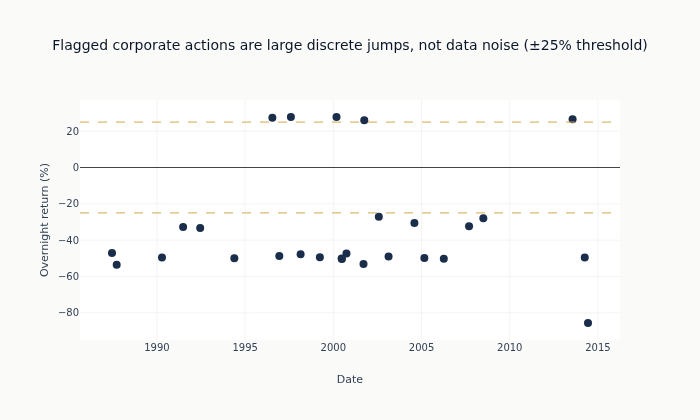

In [22]:
fig = go.Figure(
    go.Scatter(
        x=events_table["date"].to_list(),
        y=events_table["overnight_pct"].to_list(),
        mode="markers",
        marker=dict(color=COLORS["slate"], size=8),
        text=events_table["symbol"].to_list(),
        hovertemplate="%{text}<br>%{x|%Y-%m-%d}: %{y:.1f}%<extra></extra>",
        name="Flagged event",
    )
)
fig.add_hline(y=25, line_dash="dash", line_color=COLORS["amber"], line_width=1)
fig.add_hline(y=-25, line_dash="dash", line_color=COLORS["amber"], line_width=1)
fig.update_layout(
    title="Flagged corporate actions are large discrete jumps, not data noise (±25% threshold)",
    xaxis_title="Date",
    yaxis_title="Overnight return (%)",
    height=420,
)
fig.show()

---

## Part 5: Production Quality Pipeline

Wire validation, anomaly detection, and deduplication together with
quarantine routing for critical failures.

In [23]:
def quality_check_pipeline(
    df: pl.DataFrame,
    symbol: str,
    quarantine_dir: Path,
    anomaly_cfg: AnomalyConfig | None = None,
) -> tuple[pl.DataFrame, dict]:
    """Run validation → anomaly detection → dedup; quarantine on critical issues."""
    results: dict = {
        "symbol": symbol,
        "timestamp": datetime.now().isoformat(),
        "input_rows": len(df),
        "actions": [],
    }

    validation = OHLCVValidator().validate(df)
    results["validation_issues"] = len(validation.issues)
    results["actions"].append(
        f"{'PASS' if validation.passed else 'FAIL'} Validation: {len(validation.issues)} issues"
    )

    if not validation.passed:
        critical = [i for i in validation.issues if i.severity.value == "critical"]
        if critical:
            quarantine_dir.mkdir(parents=True, exist_ok=True)
            path = quarantine_dir / f"{symbol}_{datetime.now():%Y%m%d_%H%M%S}.parquet"
            df.write_parquet(path)
            results["actions"].append(f"QUARANTINED: {path.name}")

    mgr = AnomalyManager(config=anomaly_cfg) if anomaly_cfg else AnomalyManager()
    report = mgr.analyze(df, symbol)
    results["anomaly_count"] = len(report.anomalies)
    results["actions"].append(f"Anomalies: {len(report.anomalies)}")

    duplicates = len(df) - df["timestamp"].n_unique()
    if duplicates > 0:
        df = df.unique(subset=["timestamp"], keep="last")
        results["actions"].append(f"Removed {duplicates} duplicates")

    results["output_rows"] = len(df)
    results["status"] = (
        "PASS" if validation.passed and not report.get_critical_anomalies() else "REVIEW"
    )
    return df, results

In [24]:
quarantine_dir = OUTPUT_DIR / "quarantine"
pipeline_rows = []
for symbol, df in datasets.items():
    _, result = quality_check_pipeline(df, symbol, quarantine_dir, anomaly_config)
    pipeline_rows.append(
        {
            "symbol": symbol,
            "status": result["status"],
            "input_rows": result["input_rows"],
            "output_rows": result["output_rows"],
            "validation_issues": result["validation_issues"],
            "anomalies": result["anomaly_count"],
        }
    )
pipeline_summary = pl.DataFrame(pipeline_rows)
pipeline_summary

symbol,status,input_rows,output_rows,validation_issues,anomalies
str,str,i64,i64,i64,i64
"""AAPL""","""REVIEW""",9400,9400,1,516
"""MSFT""","""REVIEW""",8076,8076,1,503
"""GOOGL""","""REVIEW""",3424,3424,0,254
"""NVDA""","""REVIEW""",4825,4825,1,393
"""FB""","""REVIEW""",1472,1472,0,104


---

## Key Takeaways

Quality-pipeline profile across five large-cap symbols (AAPL, MSFT, GOOGL,
NVDA, FB) on the legacy Wiki/Quandl panel (1962-01 → 2018-03).

### Quantitative Findings
- **Structural validation**: All five symbols pass the OHLCVValidator with
  only an `extreme_returns` warning — that warning fires on the same large
  moves the corporate-action detector flags below.
- **Synthetic-fault detection**: injecting a `high < low` block, a negative
  volume, and a null close into AAPL makes the validator return
  `passed=False` with 4 errors and 0 critical: one per fault (`null_values`,
  two `price_consistency` checks, and `negative_volume`), catching every
  injected fault.
- **Return-outlier detector method spread (AAPL, threshold = 3.0)**:
  MAD = 336 events, Z-score = 83, IQR = 69. MAD is most sensitive in the
  tails because the AAPL return distribution is heavy-tailed; the top MAD
  events are the four AAPL stock splits and the 2000-09-29 earnings crash.
- **Volume spikes**: 180 AAPL events at threshold 3.0; the largest is
  2014-09-09 (~3.2× the 20-day average), the eve of the iPhone 6 launch.
- **Price staleness**: 0 events on AAPL — the legacy panel is clean for
  this symbol.
- **PSI (AAPL daily returns, halves split)**: 0.118 ⇒ moderate shift.
  Baseline 1980-12-12 → 1999-07-21, current 1999-07-21 → 2018-03-27 — the
  regime change between the two halves is detectable but not extreme.
- **Hygiene**: The only >5-day gap is the 2001-09-10 → 09-17 NYSE closure
  following 9/11, present in the three symbols listed before that date
  (AAPL, MSFT, NVDA); GOOGL and FB IPO'd later. Across the universe the
  corporate-action detector flags 27 events at the 25% threshold,
  dominated by AAPL/MSFT/NVDA splits and the GOOGL Class C distribution
  (2014-04-03).

### Implications for Practitioners
- **Pre-adjustment matters**: An unadjusted historical panel makes the
  anomaly detectors fire on real corporate events. Either adjust upstream
  or maintain a corporate-action whitelist that the pipeline consults
  before quarantining.
- **MAD over Z-score**: For heavy-tailed financial returns, MAD's tail
  sensitivity is a feature; the operator must classify each event rather
  than rely on a single auto-threshold.
- **PSI as alarm, not classifier**: A moderate shift between two 19-year
  halves is unsurprising; PSI is most useful at the rolling-30-day
  timescale where regime changes manifest faster.

**Next**: `14_point_in_time_validation` adds the temporal dimension
(bitemporal queries) on top of the structural checks shown here.